# Computational Complexity

## Introduction

When you write code for statistical computing, you often face a fundamental question: *will this finish in a reasonable amount of time?* Profiling tools like `timeit` and `cProfile` tell you how long your current code takes. But they don't tell you what happens when you scale up. What happens when your dataset grows from 1,000 observations to 1,000,000, or when you add more features to your model?

Computational complexity gives you the language and tools to reason about *how algorithms scale*. Instead of measuring exact runtimes, you characterize the relationship between input size and computational cost. This lets you:

* Predict whether an algorithm is feasible before running it
* Compare algorithms without benchmarking every possible input size
* Identify the bottleneck in a multi-step pipeline
* Choose between exact and approximate methods

### Motivating Example

Suppose you need to find duplicate values in a list. Here are three approaches:

In [41]:
import time
import numpy as np


def has_duplicates_brute(lst):
    """Check every pair. O(n^2)."""
    n = len(lst)
    for i in range(n):
        for j in range(i + 1, n):
            if lst[i] == lst[j]:
                return True
    return False


def has_duplicates_sort(lst):
    """Sort, then check neighbors. O(n log n)."""
    sorted_lst = sorted(lst)
    for i in range(len(sorted_lst) - 1):
        if sorted_lst[i] == sorted_lst[i + 1]:
            return True
    return False


def has_duplicates_set(lst):
    """Use a set. O(n)."""
    # O(n) because building a set iterates through the list once,
    # and each insertion/lookup in a hash set is O(1) on average.
    return len(set(lst)) != len(lst)


# Time each approach at different scales
for n in [1000, 2000, 4000, 8000]:
    lst = list(np.random.choice(n * 10, n, replace=False))
    times = {}
    for name, func in [
        ("brute", has_duplicates_brute),
        ("sort", has_duplicates_sort),
        ("set", has_duplicates_set),
    ]:
        start = time.time()
        for _ in range(10):
            func(lst)
        times[name] = (time.time() - start) / 10
    print(
        f"n={n:>6d}: brute={times['brute']:.4f}s, "
        f"sort={times['sort']:.4f}s, set={times['set']:.4f}s"
    )

n=  1000: brute=0.0136s, sort=0.0001s, set=0.0000s
n=  2000: brute=0.0397s, sort=0.0002s, set=0.0001s
n=  4000: brute=0.1589s, sort=0.0006s, set=0.0001s
n=  8000: brute=0.6448s, sort=0.0012s, set=0.0002s


As `n` grows, the brute-force approach slows down dramatically while the set-based approach barely changes. The difference isn't about clever coding tricks -- it's about fundamentally different scaling behavior.

## Big-O Notation

Big-O notation describes how an algorithm's resource usage (time or space) grows as the input size grows. When we say an algorithm is $O(n^2)$, we mean its cost grows *at most* proportionally to the square of the input size.

### Formal Definitions

**Big-O (upper bound):** $f(n)$ is $O(g(n))$ if there exist constants $c > 0$ and $n_0$ such that $f(n) \leq c \cdot g(n)$ for all $n \geq n_0$. This says $f$ grows no faster than $g$, up to a constant factor.

**Big-$\Theta$ (tight bound):** $f(n)$ is $\Theta(g(n))$ if there exist constants $c_1, c_2 > 0$ and $n_0$ such that $c_1 \cdot g(n) \leq f(n) \leq c_2 \cdot g(n)$ for all $n \geq n_0$. This says $f$ grows at exactly the same rate as $g$. For example, the function $3n^2 + 5n$ is both $O(n^2)$ and $\Theta(n^2)$, but it is also $O(n^3)$ (Big-O only guarantees an upper bound).

**Little-o (strict upper bound):** $f(n)$ is $o(g(n))$ if $\lim_{n \to \infty} f(n) / g(n) = 0$. This says $f$ grows *strictly slower* than $g$. For example, $n$ is $o(n^2)$, but $n^2$ is *not* $o(n^2)$.

**Conventional usage:** Formally, $O(n^2)$ only means "at most $n^2$", so saying an algorithm is $O(n^{10})$ would be technically correct even if it runs in linear time. In practice, when people say an algorithm is $O(n^2)$, they mean $\Theta(n^2)$. It is a *tight* characterization, not just any upper bound. We follow this convention throughout the course: Big-O describes the tightest known bound.

### Key Rules

* **Drop constants:** $3n^2$ is $O(n^2)$. The constant 3 doesn't affect the growth rate.
* **Drop lower-order terms:** $n^2 + 100n + 500$ is $O(n^2)$. For large $n$, the $n^2$ term dominates.
* **Worst case by default:** Unless stated otherwise, Big-O describes the worst-case scenario.

### Common Complexity Classes

| Complexity | Name | Example |
|---|---|---|
| $O(1)$ | Constant | Dictionary lookup, array index access |
| $O(\log n)$ | Logarithmic | Binary search |
| $O(n)$ | Linear | Single pass through an array |
| $O(n \log n)$ | Linearithmic | Sorting (mergesort, timsort) |
| $O(n^2)$ | Quadratic | Pairwise comparisons |
| $O(n^3)$ | Cubic | Matrix multiplication (naive), matrix inversion |
| $O(2^n)$ | Exponential | All subsets, naive recursive Fibonacci |

The following code visualizes how these grow:

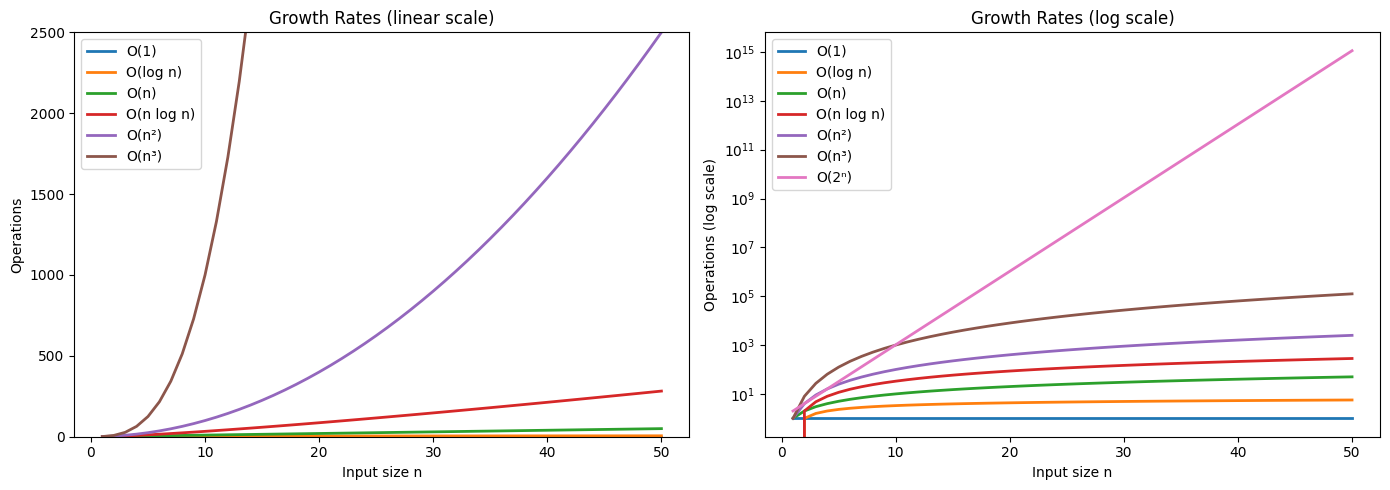

In [42]:
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(1, 51)
complexities = {
    "O(1)": np.ones_like(n, dtype=float),
    "O(log n)": np.log2(n),
    "O(n)": n.astype(float),
    "O(n log n)": n * np.log2(n),
    "O(n²)": n**2.0,
    "O(n³)": n**3.0,
    "O(2ⁿ)": 2.0**n,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale (exclude exponential to keep readable)
for name, values in complexities.items():
    if name != "O(2ⁿ)":
        axes[0].plot(n, values, label=name, linewidth=2)
axes[0].set_xlabel("Input size n")
axes[0].set_ylabel("Operations")
axes[0].set_title("Growth Rates (linear scale)")
axes[0].legend()
axes[0].set_ylim(0, 2500)

# Log scale (all classes)
for name, values in complexities.items():
    axes[1].plot(n, values, label=name, linewidth=2)
axes[1].set_xlabel("Input size n")
axes[1].set_ylabel("Operations (log scale)")
axes[1].set_title("Growth Rates (log scale)")
axes[1].set_yscale("log")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/complexity_growth.png", dpi=150, bbox_inches="tight")

The log-scale plot reveals why exponential algorithms are impractical: even at n=50, $O(2^n)$ requires over 10^15 operations.

### Question

What is the time complexity of this function?

In [43]:
def process(data):
    n = len(data)
    total = 0
    for i in range(n):
        for j in range(10):
            total += data[i] * j
    return total

### Answer

$O(n)$. Although there are nested loops, the inner loop runs a fixed 10 times regardless of `n`. The total number of operations is 10n, which is $O(n)$. A constant inner bound doesn't add a factor of n.

## Analyzing Time Complexity

### Simple and Sequential Loops

A single loop over n elements is $O(n)$. Sequential loops (one after another) are also $O(n)$ because we add their costs:

In [44]:
# O(n) + O(n) = O(n)
def compute_stats(data):
    n = len(data)
    total = 0
    for x in data:       # O(n)
        total += x
    mean = total / n

    variance = 0
    for x in data:       # O(n)
        variance += (x - mean) ** 2
    return mean, variance / n

### Nested Loops

Nested loops multiply. If the outer loop runs n times and the inner loop runs n times, the total is $O(n^2)$:

In [45]:
# O(n * p^2): pairwise correlations between p variables
def pairwise_correlations(X):
    """X is n x p. Compute p x p correlation matrix."""
    n, p = X.shape
    # Center columns: O(n * p)
    means = X.mean(axis=0)
    X_centered = X - means

    corr = np.zeros((p, p))
    for i in range(p):           # p iterations
        for j in range(i, p):    # up to p iterations
            # Dot product: O(n)
            r = np.dot(X_centered[:, i], X_centered[:, j])
            r /= np.sqrt(
                np.dot(X_centered[:, i], X_centered[:, i])
                * np.dot(X_centered[:, j], X_centered[:, j])
            )
            corr[i, j] = corr[j, i] = r
    return corr

The outer two loops give $O(p^2)$ iterations, each doing an $O(n)$ dot product. Total: $O(n * p^2)$.

### Recursive Functions

Recursion can hide dramatic complexity differences. Consider Fibonacci:

In [46]:
# Naive recursion: O(2^n)
def fib_naive(n):
    if n <= 1:
        return n
    return fib_naive(n - 1) + fib_naive(n - 2)


# Memoized: O(n)
from functools import lru_cache


@lru_cache(maxsize=None)
def fib_memo(n):
    if n <= 1:
        return n
    return fib_memo(n - 1) + fib_memo(n - 2)

The naive version recomputes the same subproblems exponentially many times. Each call branches into two more calls, giving $O(2^n)$. Memoization stores results, so each value from 0 to n is computed exactly once: $O(n)$.

In [47]:
import time

for n in [5, 10, 20, 40]:
    start = time.time()
    fib_naive(n)
    naive_time = time.time() - start

    fib_memo.cache_clear()
    start = time.time()
    fib_memo(n)
    memo_time = time.time() - start

    print(f"n={n}: naive={naive_time:.6f}s, memoized={memo_time:.6f}s")

n=5: naive=0.000002s, memoized=0.000001s
n=10: naive=0.000006s, memoized=0.000002s
n=20: naive=0.000566s, memoized=0.000004s
n=40: naive=8.053512s, memoized=0.000017s


### Question

What is the time complexity of this function?

In [48]:
def mystery(n):
    total = 0
    i = 1
    while i < n:
        for j in range(n):
            total += 1
        i *= 2
    return total

### Answer

$O(n \log n)$. The `while` loop doubles `i` each iteration, so it runs $\log_2(n)$ times. The inner `for` loop runs n times on each iteration of the while loop. Total: n * log(n).

## Space Complexity

Space complexity measures how much *additional* memory an algorithm uses beyond its input. This is often the binding constraint in scientific computing -- your algorithm might be fast enough, but it runs out of memory.

Unless otherwise stated, in this lecture, memory refers to the *auxiliary space*, which is the extra memory an algorithm allocates on top of the input data. It excludes the memory used to store the input itself. For example, if you receive an array of size $n$ and create a second array of size $n$ to store results, the auxiliary space is $O(n)$, even though the total memory used is $2n$.

In [49]:
import sys


# O(1) space: in-place computation
def running_mean_inplace(data):
    """Compute running mean without extra arrays."""
    total = 0
    for i, x in enumerate(data):
        total += x
        data[i] = total / (i + 1)
    return data


# O(n) space: creates a new array
def running_mean_copy(data):
    """Compute running mean with a new output array."""
    n = len(data)
    result = np.zeros(n)  # n extra floats
    total = 0
    for i in range(n):
        total += data[i]
        result[i] = total / (i + 1)
    return result


# O(n^2) space: distance matrix
def pairwise_distances(points):
    """Compute all pairwise distances. Stores n x n matrix."""
    n = len(points)
    dist = np.zeros((n, n))  # n^2 extra floats
    for i in range(n):
        for j in range(i + 1, n):
            d = np.sqrt(np.sum((points[i] - points[j]) ** 2))
            dist[i, j] = dist[j, i] = d
    return dist

### Memory in Practice

A float64 value uses 8 bytes. For an n x n matrix:

| n | Memory |
|---|---|
| 1,000 | 8 MB |
| 10,000 | 800 MB |
| 50,000 | 20 GB |
| 100,000 | 80 GB |

This is why n x n distance or kernel matrices often become the bottleneck long before time complexity is an issue.

### Question

You need to compute a pairwise Euclidean distance matrix for 50,000 data points (each with 100 features). Each distance is stored as a float64. How much memory does the distance matrix require, and is this feasible on a machine with 16 GB of RAM?

### Answer

The distance matrix is 50,000 x 50,000 = 2.5 x 10^9 entries. At 8 bytes per float64, that's 2.5 x 10^9 * 8 = 20 x 10^9 bytes = 20 GB. This exceeds 16 GB of RAM, so it won't fit in memory. You would need to either compute distances on the fly, use a sparse representation (if most distances aren't needed), or work in batches.

## Complexity of Common Operations

### Python Built-in Data Structures

| Operation | list | dict | set |
|---|---|---|---|
| Index/lookup | $O(1)$ | $O(1)$ avg | - |
| Search (`in`) | $O(n)$ | $O(1)$ avg | $O(1)$ avg |
| Append/insert end | $O(1)$ amortized | $O(1)$ avg | $O(1)$ avg |
| Insert at position | $O(n)$ | - | - |
| Delete | $O(n)$ | $O(1)$ avg | $O(1)$ avg |
| Sort | $O(n \log n)$ | - | - |

The difference between $O(n)$ and $O(1)$ lookup matters enormously at scale:

In [50]:
import time

n = 1000000
data_list = list(range(n))
data_set = set(range(n))

# Search for elements near the end
targets = list(range(n - 100, n))

start = time.time()
for t in targets:
    _ = t in data_list
list_time = time.time() - start

start = time.time()
for t in targets:
    _ = t in data_set
set_time = time.time() - start

print(f"List search:  {list_time:.4f}s")
print(f"Set search:   {set_time:.6f}s")
print(f"Speedup:      {list_time / set_time:.0f}x")

List search:  0.5210s
Set search:   0.000042s
Speedup:      12417x


### NumPy and Matrix Operations

| Operation | Complexity | Example |
|---|---|---|
| Element-wise (+, *, exp) | $O(n)$ | `np.exp(x)` for vector of length n |
| Dot product | $O(n)$ | `np.dot(x, y)` for vectors of length n |
| Matrix-vector multiply | $O(np)$ | `A @ x` for A of shape $(n, p)$ |
| Matrix multiply | $O(npm)$ | `A @ B` for $(n,p) \times (p,m)$ |
| Matrix inverse | $O(n^3)$ | `np.linalg.inv(A)` for $n \times n$ |
| Eigendecomposition | $O(n^3)$ | `np.linalg.eigh(A)` for $n \times n$ |
| Cholesky decomposition | $O(n^3)$ | `np.linalg.cholesky(A)` for $n \times n$ |
| SVD | $O(\min(n,p)^2 \cdot \max(n,p))$ | `np.linalg.svd(A)` for $n \times p$ |
| Solving linear system | $O(n^3)$ | `np.linalg.solve(A, b)` for $n \times n$ |

Note that inverse, eigendecomposition, and Cholesky are all $O(n^3)$, but with very different constants. We'll verify this shortly.

In [51]:
import numpy as np
import time

# Verify matrix multiplication scaling
for n in [400, 800, 1600, 3200, 6400]:
    A = np.random.randn(n, n)
    B = np.random.randn(n, n)

    start = time.time()
    for _ in range(5):
        C = A @ B
    elapsed = (time.time() - start) / 5

    print(f"n={n:>5d}: {elapsed:.4f}s")

n=  400: 0.0042s
n=  800: 0.0087s
n= 1600: 0.0562s
n= 3200: 0.2877s
n= 6400: 1.4386s


When you double n, you should see roughly an 8x increase in time ($2^3 = 8$), confirming $O(n^3)$ scaling.

### Question

In ridge regression, the solution is $\hat{\beta} = (X^T X + \lambda I)^{-1} X^T y$, where $X$ is $n \times p$ and $\lambda > 0$ is the regularization parameter. Unlike ordinary least squares, the matrix $X^T X + \lambda I$ is always invertible. What is the time complexity when $n \gg p$? What about when $p \gg n$?

### Answer

The key operations are:

* $X^T X$: matrix multiply $(p, n) \times (n, p)$ → $O(np^2)$
* $X^T X + \lambda I$: add diagonal, $O(p)$
* $(X^T X + \lambda I)^{-1}$: inverse of a $p \times p$ matrix → $O(p^3)$
* $X^T y$: matrix-vector multiply $(p, n) \times (n,)$ → $O(np)$
* Final multiply: $(p, p) \times (p,)$ → $O(p^2)$

Total: $O(np^2 + p + p^3 + np + p^2)$ = $O(np^2 + p^3)$.

When **$n \gg p$**: The $O(np^2)$ term dominates. Doubling $n$ doubles the cost; doubling $p$ quadruples it.

When **$p \gg n$**: The $O(p^3)$ inverse dominates. For high-dimensional problems (e.g., genomics with $p = 500{,}000$ SNPs), this is infeasible. A common trick is the **Woodbury identity**: rewrite the solution as $\hat{\beta} = X^T(XX^T + \lambda I)^{-1}y$, which inverts an $n \times n$ matrix instead of $p \times p$, reducing the cost to $O(n^2 p + n^3)$.

## Measuring Complexity Empirically

Complexity analysis tells you the theoretical growth rate. But you can also *measure* it. This is useful for verifying your analysis, understanding library implementations, or characterizing code that's too complex to analyze by hand.

### The Log-Log Method

If runtime T(n) = c * n^k, then log T(n) = log c + k * log n. On a log-log plot, this is a straight line with slope k. So:

* Slope ~1 means $O(n)$
* Slope ~2 means $O(n^2)$
* Slope ~3 means $O(n^3)$

For $O(n \log n)$, the log-log plot is nearly linear with slope slightly above 1.

The `timeit` module (covered in [efficient code](efficient-code.md)) is ideal for getting reliable timing measurements. Here we use `time.time()` for simplicity since we're measuring larger operations.

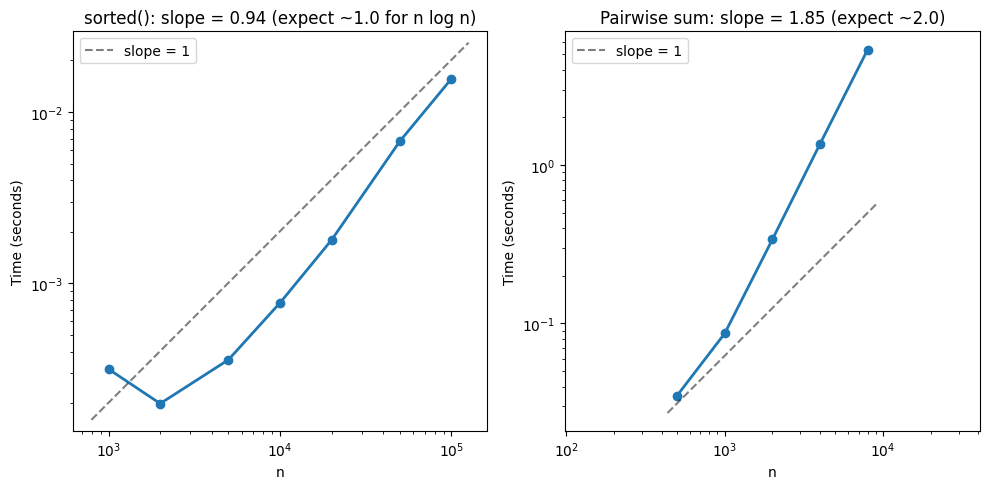

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Measure two algorithms: sorted() and pairwise sum
sizes = [1000, 2000, 5000, 10000, 20000, 50000, 100000]
sort_times = []
pairwise_times = []

for n in sizes:
    data = np.random.randn(n).tolist()

    # Sorting: expected O(n log n)
    start = time.time()
    for _ in range(5):
        sorted(data)
    sort_times.append((time.time() - start) / 5)

# Pairwise sum: expected O(n^2), use smaller sizes
pair_sizes = [500, 1000, 2000, 4000, 8000]
for n in pair_sizes:
    data = np.random.randn(n)
    start = time.time()
    total = 0.0
    for i in range(n):
        for j in range(i + 1, n):
            total += data[i] * data[j]
    pairwise_times.append(time.time() - start)

# Fit log-log slopes
log_sizes = np.log(sizes)
log_sort = np.log(sort_times)
sort_slope = linregress(log_sizes, log_sort).slope

log_pair_sizes = np.log(pair_sizes)
log_pairwise = np.log(pairwise_times)
pair_slope = linregress(log_pair_sizes, log_pairwise).slope

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].loglog(sizes, sort_times, "o-", linewidth=2)
axes[0].set_xlabel("n")
axes[0].set_ylabel("Time (seconds)")
axes[0].set_title(f"sorted(): slope = {sort_slope:.2f} (expect ~1.0 for n log n)")
axes[0].set_aspect("equal", adjustable="datalim")

axes[1].loglog(pair_sizes, pairwise_times, "o-", linewidth=2)
axes[1].set_xlabel("n")
axes[1].set_ylabel("Time (seconds)")
axes[1].set_title(f"Pairwise sum: slope = {pair_slope:.2f} (expect ~2.0)")
axes[1].set_aspect("equal", adjustable="datalim")

# Reference line with slope 1 (y = x scaling)
for ax in axes:
    xlim = ax.get_xlim()
    ref_x = np.array(xlim)
    ref_y = ref_x / ref_x[0] * ax.get_ylim()[0]
    ax.plot(ref_x, ref_y, "k--", alpha=0.5, label="slope = 1")
    ax.legend()

plt.tight_layout()
plt.savefig("figures/loglog_complexity.png", dpi=150, bbox_inches="tight")

The sort slope should be close to 1 (it's technically n log n, but log n changes slowly). The pairwise sum slope should be close to 2, confirming $O(n^2)$.

### Question

You time an algorithm at several input sizes and get:

| n | Time (seconds) |
|---|---|
| 1,000 | 0.05 |
| 2,000 | 0.19 |
| 4,000 | 0.78 |
| 8,000 | 3.10 |

Estimate the time complexity. How long would you expect the algorithm to take at n = 32,000?

### Answer

Each time n doubles, the time roughly quadruples (0.19/0.05 = 3.8, 0.78/0.19 = 4.1, 3.10/0.78 = 4.0). This is consistent with $O(n^2)$.

To predict n = 32,000: from n = 8,000 we double twice (8k -> 16k -> 32k), so the time quadruples twice: 3.10 * 4 * 4 = ~49.6 seconds.

## Practical Examples in Scientific Computing

### Matrix Operations: Same Big-O, Different Constants

Inverse, eigendecomposition, and Cholesky are all $O(n^3)$, but Cholesky is much faster in practice because it exploits symmetry and positive definiteness.

Note that these three operations serve different purposes. The inverse gives you $A^{-1}$ directly. Eigendecomposition gives you eigenvalues and eigenvectors (used for PCA, spectral methods, etc.). Cholesky gives you a lower-triangular factor $L$ such that $A = LL^T$, which is useful for solving linear systems and sampling from multivariate normals. The point here is that even when the asymptotic complexity is the same, the constant factor can differ by an order of magnitude:

In [53]:
import numpy as np
import time

results = []
for n in [200, 500, 1000, 2000]:
    # Create a symmetric positive definite matrix
    A = np.random.randn(n, n)
    A = A @ A.T + n * np.eye(n)

    timings = {}
    for name, func in [
        ("inverse", lambda: np.linalg.inv(A)),
        ("eigendecomp", lambda: np.linalg.eigh(A)),
        ("cholesky", lambda: np.linalg.cholesky(A)),
    ]:
        start = time.time()
        for _ in range(3):
            func()
        timings[name] = (time.time() - start) / 3

    print(
        f"n={n:>5d}: inv={timings['inverse']:.4f}s, "
        f"eig={timings['eigendecomp']:.4f}s, chol={timings['cholesky']:.4f}s"
    )

n=  200: inv=0.0169s, eig=0.0040s, chol=0.0003s
n=  500: inv=0.0038s, eig=0.0310s, chol=0.0011s
n= 1000: inv=0.0252s, eig=0.0998s, chol=0.0055s
n= 2000: inv=0.0894s, eig=0.6660s, chol=0.0416s


This is why numerical linear algebra prefers Cholesky decomposition when the matrix is symmetric positive definite (covariance matrices, precision matrices, kernel matrices).

### Sorting and Searching

Binary search is $O(\log n)$ but requires sorted data. Linear search is $O(n)$ but works on any list. Which is better depends on how many queries you make:

In [54]:
import bisect
import time
import numpy as np

n = 1000000
data = sorted(np.random.randn(n).tolist())
queries = np.random.randn(1000).tolist()

# Linear search: O(n) per query, O(n * q) total
start = time.time()
for q in queries:
    for x in data:
        if x >= q:
            break
linear_time = time.time() - start

# Binary search: O(log n) per query, O(q * log n) total
start = time.time()
for q in queries:
    bisect.bisect_left(data, q)
binary_time = time.time() - start

print(f"Linear search (1000 queries): {linear_time:.3f}s")
print(f"Binary search (1000 queries): {binary_time:.5f}s")

Linear search (1000 queries): 13.609s
Binary search (1000 queries): 0.00067s


### Question

K-nearest neighbors (KNN) classification for a single test point involves computing the distance from the test point to all n training points, then finding the k smallest. If each point has p features, what is the time complexity for classifying one test point? What about classifying m test points?

How might you speed this up?

### Answer

For one test point: computing the distance to a single training point requires $O(p)$ operations (subtract two p-dimensional vectors, square each element, sum, take square root). Repeating this for all n training points gives $O(np)$. Finding the k smallest distances can be done in $O(n)$ with a partial sort algorithm like `numpy.argpartition` (or $O(n \log k)$ with a heap). Since typically k << n, the distance computation dominates. Total: $O(np)$.

For m test points: $O(mnp)$. Each test point requires $O(np)$ independently.

To speed this up, you can preprocess the training data into a spatial data structure like a **KD-tree**. A KD-tree recursively partitions the feature space along coordinate axes, so that during a query you can prune large regions of the space without computing distances to every point. Building the tree is $O(np \log n)$, but each query then takes $O(p \log n)$ on average instead of $O(np)$. For m queries, the total becomes $O(np \log n + mp \log n)$ instead of $O(mnp)$. This is a significant improvement when m is large. However, KD-trees degrade to $O(np)$ per query in high dimensions (roughly p > 20), so they work best when p is small.

## Trade-offs

### Time vs Space

A classic trade-off: precompute results to save time, at the cost of memory.

In [55]:
import numpy as np
import time

n = 5000
p = 50  # number of features per point
points = np.random.randn(n, p)

# Approach 1: Precompute distance matrix (O(n^2) space, O(n^2 * p) time once)
start = time.time()
from scipy.spatial.distance import cdist

dist_matrix = cdist(points, points)
precompute_time = time.time() - start
memory_mb = dist_matrix.nbytes / 1e6

# Access 10000 random pairs
pairs = np.random.randint(0, n, size=(10000, 2))
start = time.time()
for i, j in pairs:
    _ = dist_matrix[i, j]
lookup_time = time.time() - start

# Approach 2: Compute on the fly (O(1) space, O(p) per lookup)
start = time.time()
for i, j in pairs:
    _ = np.sqrt(np.sum((points[i] - points[j]) ** 2))
compute_time = time.time() - start

print(f"Precomputed: {precompute_time:.3f}s build, {lookup_time:.4f}s and {memory_mb:.1f} MB for {len(pairs)} lookups")
print(f"On-the-fly:  {compute_time:.3f}s for {len(pairs)} lookups")

Precomputed: 0.268s build, 0.0059s and 200.0 MB for 10000 lookups
On-the-fly:  0.029s for 10000 lookups


If you access most pairs, precomputing wins. If you only need a few pairs, computing on the fly avoids the memory cost.

### Exact vs Approximate

When exact computation is too expensive, approximate methods can give you most of the accuracy at a fraction of the cost.

In [56]:
import numpy as np
import time
from sklearn.utils.extmath import randomized_svd

# Smaller matrix to keep demo under ~10s total
n, p = 5000, 2000
X = np.random.randn(n, p)
k = 50  # number of components we want

# Full SVD: O(min(n,p)^2 * max(n,p))
start = time.time()
U_full, s_full, Vt_full = np.linalg.svd(X, full_matrices=False)
full_time = time.time() - start

# Randomized SVD: O(n * p * k) where k << min(n, p)
start = time.time()
U_rand, s_rand, Vt_rand = randomized_svd(X, n_components=k, random_state=42)
rand_time = time.time() - start

# Compare accuracy (top k singular values)
relative_error = np.max(np.abs(s_full[:k] - s_rand) / s_full[:k])

print(f"Full SVD:       {full_time:.2f}s")
print(f"Randomized SVD: {rand_time:.2f}s")
print(f"Speedup:        {full_time / rand_time:.1f}x")
print(f"Max relative error in top {k} singular values: {relative_error:.2e}")

Full SVD:       2.44s
Randomized SVD: 0.26s
Speedup:        9.5x
Max relative error in top 50 singular values: 3.43e-02


Randomized SVD is standard practice for PCA on large matrices. When you only need the top k components, there's no reason to compute all min(n, p) of them.

## Exercises

**Problem 1.** The following function computes the sample covariance matrix of a data matrix `X` ($n$ observations, $p$ variables):

```python
def covariance_naive(X):
    n, p = X.shape
    means = np.mean(X, axis=0)
    cov = np.zeros((p, p))
    for i in range(p):
        for j in range(p):
            total = 0.0
            for k in range(n):
                total += (X[k, i] - means[i]) * (X[k, j] - means[j])
            cov[i, j] = total / (n - 1)
    return cov
```

(a) What is the time complexity?
(b) The function computes both `cov[i, j]` and `cov[j, i]` separately. How would exploiting symmetry change the complexity?
(c) How would you rewrite this using NumPy to eliminate the explicit loops?

**Answer:**

(a) Three nested loops: the outer two iterate over all $p \times p$ pairs, and the inner loop runs $n$ times. Total: $O(np^2)$.

(b) Exploiting symmetry ($\text{cov}[i,j] = \text{cov}[j,i]$) halves the number of inner-loop executions from $p^2$ to $p(p+1)/2$. The complexity is still $O(np^2)$ -- the constant factor drops by ~2x, but the asymptotic class is unchanged.

(c) Center the matrix once: `X_centered = X - X.mean(axis=0)`. Then the covariance matrix is a single matrix multiply: `cov = (X_centered.T @ X_centered) / (n - 1)`. This is still $O(np^2)$ but uses optimized BLAS routines, which are much faster than Python loops.

**Problem 2.** You have a function that checks whether any row in an $n \times p$ matrix is a duplicate of another row:

```python
def has_duplicate_rows(X):
    n = X.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            if np.array_equal(X[i], X[j]):
                return True
    return False
```

What is the time and space complexity?

**Answer:**

Time: the nested loops compare $O(n^2)$ pairs, each comparison takes $O(p)$. Total: $O(n^2 p)$. Space: $O(1)$ auxiliary (no extra data structures).

**Problem 3.** Consider computing the moving average of a time series with a window of size $w$:

```python
def moving_average_naive(data, w):
    n = len(data)
    result = np.zeros(n - w + 1)
    for i in range(n - w + 1):
        result[i] = np.mean(data[i:i + w])
    return result
```

(a) What is the time complexity in terms of $n$ and $w$?
(b) Describe an $O(n)$ approach that avoids recomputing the sum from scratch at each position.

**Answer:**

(a) The loop runs $n - w + 1$ times, and each `np.mean` sums $w$ elements. Total: $O((n - w) \cdot w)$. In the worst case ($w \approx n/2$), this is $O(n^2)$.

(b) Use a running sum. Compute the sum of the first window, then for each subsequent position, subtract the element leaving the window and add the element entering it. Each update is $O(1)$, so the total is $O(n)$:

```python
def moving_average_fast(data, w):
    n = len(data)
    result = np.zeros(n - w + 1)
    window_sum = np.sum(data[:w])
    result[0] = window_sum / w
    for i in range(1, n - w + 1):
        window_sum += data[i + w - 1] - data[i - 1]
        result[i] = window_sum / w
    return result
```

**Problem 4.** You need to repeatedly solve linear systems $Ax = b_i$ for $i = 1, \ldots, m$, where $A$ is a fixed $n \times n$ symmetric positive definite matrix and each $b_i$ is a different right-hand side vector.

(a) What is the time complexity if you use `np.linalg.solve(A, b)` independently for each $b_i$?
(b) How can you reduce the total cost using a Cholesky decomposition? What is the new complexity?

**Answer:**

(a) Each call to `np.linalg.solve` factors $A$ (via LU decomposition, $O(n^3)$) then solves ($O(n^2)$). Repeating $m$ times: $O(mn^3)$.

(b) Factor $A$ once using Cholesky: $A = LL^T$ at cost $O(n^3)$. Then each system $LL^T x = b_i$ is solved by two triangular solves (forward and back substitution), each $O(n^2)$. Total: $O(n^3 + mn^2)$. When $m$ is large, this is dramatically faster since the expensive $O(n^3)$ factorization is done only once.

```python
import scipy.linalg
L = scipy.linalg.cholesky(A, lower=True)  # O(n^3), done once
for b in right_hand_sides:
    x = scipy.linalg.cho_solve((L, True), b)  # O(n^2) each
```

**Problem 5.** You are building a spam classifier. During training, you compute the tf-idf features (relative frequency of each unique word) for 100,000 emails, each with a vocabulary of 50,000 words. Most emails use fewer than 200 unique words.

(a) What is the memory cost of storing the tf-idf matrix as a dense numpy array (float64)?
(b) What data structure would you use instead, and roughly how much memory would it require?
(c) If you need to compute pairwise cosine similarities between all emails, what is the time complexity using the dense representation? Is this feasible?

**Answer:**

(a) Dense matrix: $100{,}000 \times 50{,}000 \times 8$ bytes $= 40 \times 10^9$ bytes $= 40$ GB.

(b) Use a **sparse matrix** (e.g., `scipy.sparse.csr_matrix`). With ~200 nonzero entries per row, the total nonzeros are $100{,}000 \times 200 = 2 \times 10^7$. Each nonzero stores a float64 (8 bytes) and a column index (4 bytes), plus row pointers. Roughly: $2 \times 10^7 \times 12 \approx 240$ MB, which is over 100x smaller than dense.

(c) Pairwise cosine similarity between all $n = 100{,}000$ emails requires $O(n^2)$ similarity computations. Each cosine similarity of two dense vectors of length $p = 50{,}000$ is $O(p)$. Total: $O(n^2 p) = O(100{,}000^2 \times 50{,}000) = O(5 \times 10^{14})$. This is not feasible. In practice, you would use sparse matrix operations (which skip zero entries) or approximate methods like locality-sensitive hashing.

## Summary

* **Big-O notation** describes how algorithms scale with input size, ignoring constants and lower-order terms.
* **Time complexity** is determined by counting loop iterations, recursive calls, and the cost of operations within them.
* **Space complexity** measures additional memory usage and is often the practical bottleneck in scientific computing (n x n matrices grow fast).
* **Python data structures** have different complexities: use sets/dicts for $O(1)$ membership testing, not lists.
* **NumPy/matrix operations** are typically $O(n^3)$ for decompositions and inversions. Cholesky is preferred when applicable.
* **Empirical measurement** via log-log plots lets you verify complexity by estimating the slope (exponent).
* **Trade-offs** between time and space, exact and approximate methods are central decisions in scientific computing. Randomized methods are often the practical choice for large-scale problems.

## Recommended Resources

* [Big-O Cheat Sheet](https://www.bigocheatsheet.com/): common data structure and algorithm complexities
* [Python Time Complexity](https://wiki.python.org/moin/TimeComplexity): official wiki on built-in operation costs
* [Introduction to Algorithms (CLRS)](https://mitpress.mit.edu/books/introduction-algorithms-fourth-edition): the standard reference for algorithm analysis
* [Algorithms (Sedgewick and Wayne)](https://algs4.cs.princeton.edu/home/): accessible textbook with Java implementations and excellent visualizations
* [Finding Structure with Randomness (Halko, Martinsson, Tropp, 2011)](https://arxiv.org/abs/0909.4061): the foundational paper on randomized matrix decompositions